In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import sys
sys.path.append('..')
from src import sp_eda, sp_visualizacion as vis

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, KNNImputer


In [17]:
df= pd.read_csv('../data_processed/ba_limpieza.csv', parse_dates=['Date'])
df.head(3)

,Age,Job,Marital,Education,Default,Housing,Loan,Contact,Duration,Campaign,...,Nr.Employed,Y,Date,Latitude,Longitude,Id_,Year,Month,Day_Name,Quarter
0,NaN,housemaid,married,basic.4y,no,no,no,telephone,261,1,...,5191.0,no,2019-08-02,41.495,-71.233,089b39d8-e4d0-461b-87d4-814d71e0e079,2019.0,august,friday,3.0
1,57.0,services,married,high.school,no,no,no,telephone,149,1,...,5191.0,no,2016-09-14,34.601,-83.923,e9d37224-cb6f-4942-98d7-46672963d097,2016.0,september,wednesday,3.0
2,37.0,services,married,high.school,no,yes,no,telephone,226,1,...,5191.0,no,2019-02-15,34.939,-94.847,3f9f49b5-e410-4948-bf6e-f9244f04918b,2019.0,february,friday,1.0


In [18]:
df.select_dtypes(include=np.number).columns

Index(['Age', 'Duration', 'Campaign', 'Pdays', 'Previous', 'Emp.Var.Rate',
       'Cons.Price.Idx', 'Cons.Conf.Idx', 'Euribor3M', 'Nr.Employed',
       'Latitude', 'Longitude', 'Year', 'Quarter'],
      dtype='object')

In [19]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Age,37880.0,39.977112,17.0,32.0,38.0,47.0,98.0,10.437957
Duration,43000.0,257.739279,0.0,102.0,179.0,319.0,4918.0,258.666033
Campaign,43000.0,2.567233,1.0,1.0,2.0,3.0,56.0,2.772294
Pdays,43000.0,962.330953,0.0,999.0,999.0,999.0,999.0,187.260394
Previous,43000.0,0.174023,0.0,0.0,0.0,0.0,7.0,0.497366
Emp.Var.Rate,43000.0,0.077128,-3.4,-1.8,1.1,1.4,1.4,1.573898
Cons.Price.Idx,42529.0,93.574219,92.201,93.075,93.749,93.994,94.767,0.579548
Cons.Conf.Idx,43000.0,-40.509049,-50.8,-42.7,-41.8,-36.4,-26.9,4.637186
Euribor3M,33744.0,3.616521,0.634,1.344,4.857,4.961,5.045,1.737117
Nr.Employed,43000.0,5166.852602,4963.6,5099.1,5191.0,5228.1,5228.1,72.411125


In [20]:
columnas_num = df.select_dtypes(include=np.number).columns.tolist()
lista_eliminar = ['Pdays','Previous', 'Latitude', 'Longitude','Year', 'Quarter']
for col in lista_eliminar:
     columnas_num.remove(col)

In [21]:
df[columnas_num].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,37880.0,39.977112,10.437957,17.000,32.000,38.000,47.000,98.000
Duration,43000.0,257.739279,258.666033,0.000,102.000,179.000,319.000,4918.000
Campaign,43000.0,2.567233,2.772294,1.000,1.000,2.000,3.000,56.000
Emp.Var.Rate,43000.0,0.077128,1.573898,-3.400,-1.800,1.100,1.400,1.400
Cons.Price.Idx,42529.0,93.574219,0.579548,92.201,93.075,93.749,93.994,94.767
Cons.Conf.Idx,43000.0,-40.509049,4.637186,-50.800,-42.700,-41.800,-36.400,-26.900
Euribor3M,33744.0,3.616521,1.737117,0.634,1.344,4.857,4.961,5.045
Nr.Employed,43000.0,5166.852602,72.411125,4963.600,5099.100,5191.000,5228.100,5228.100


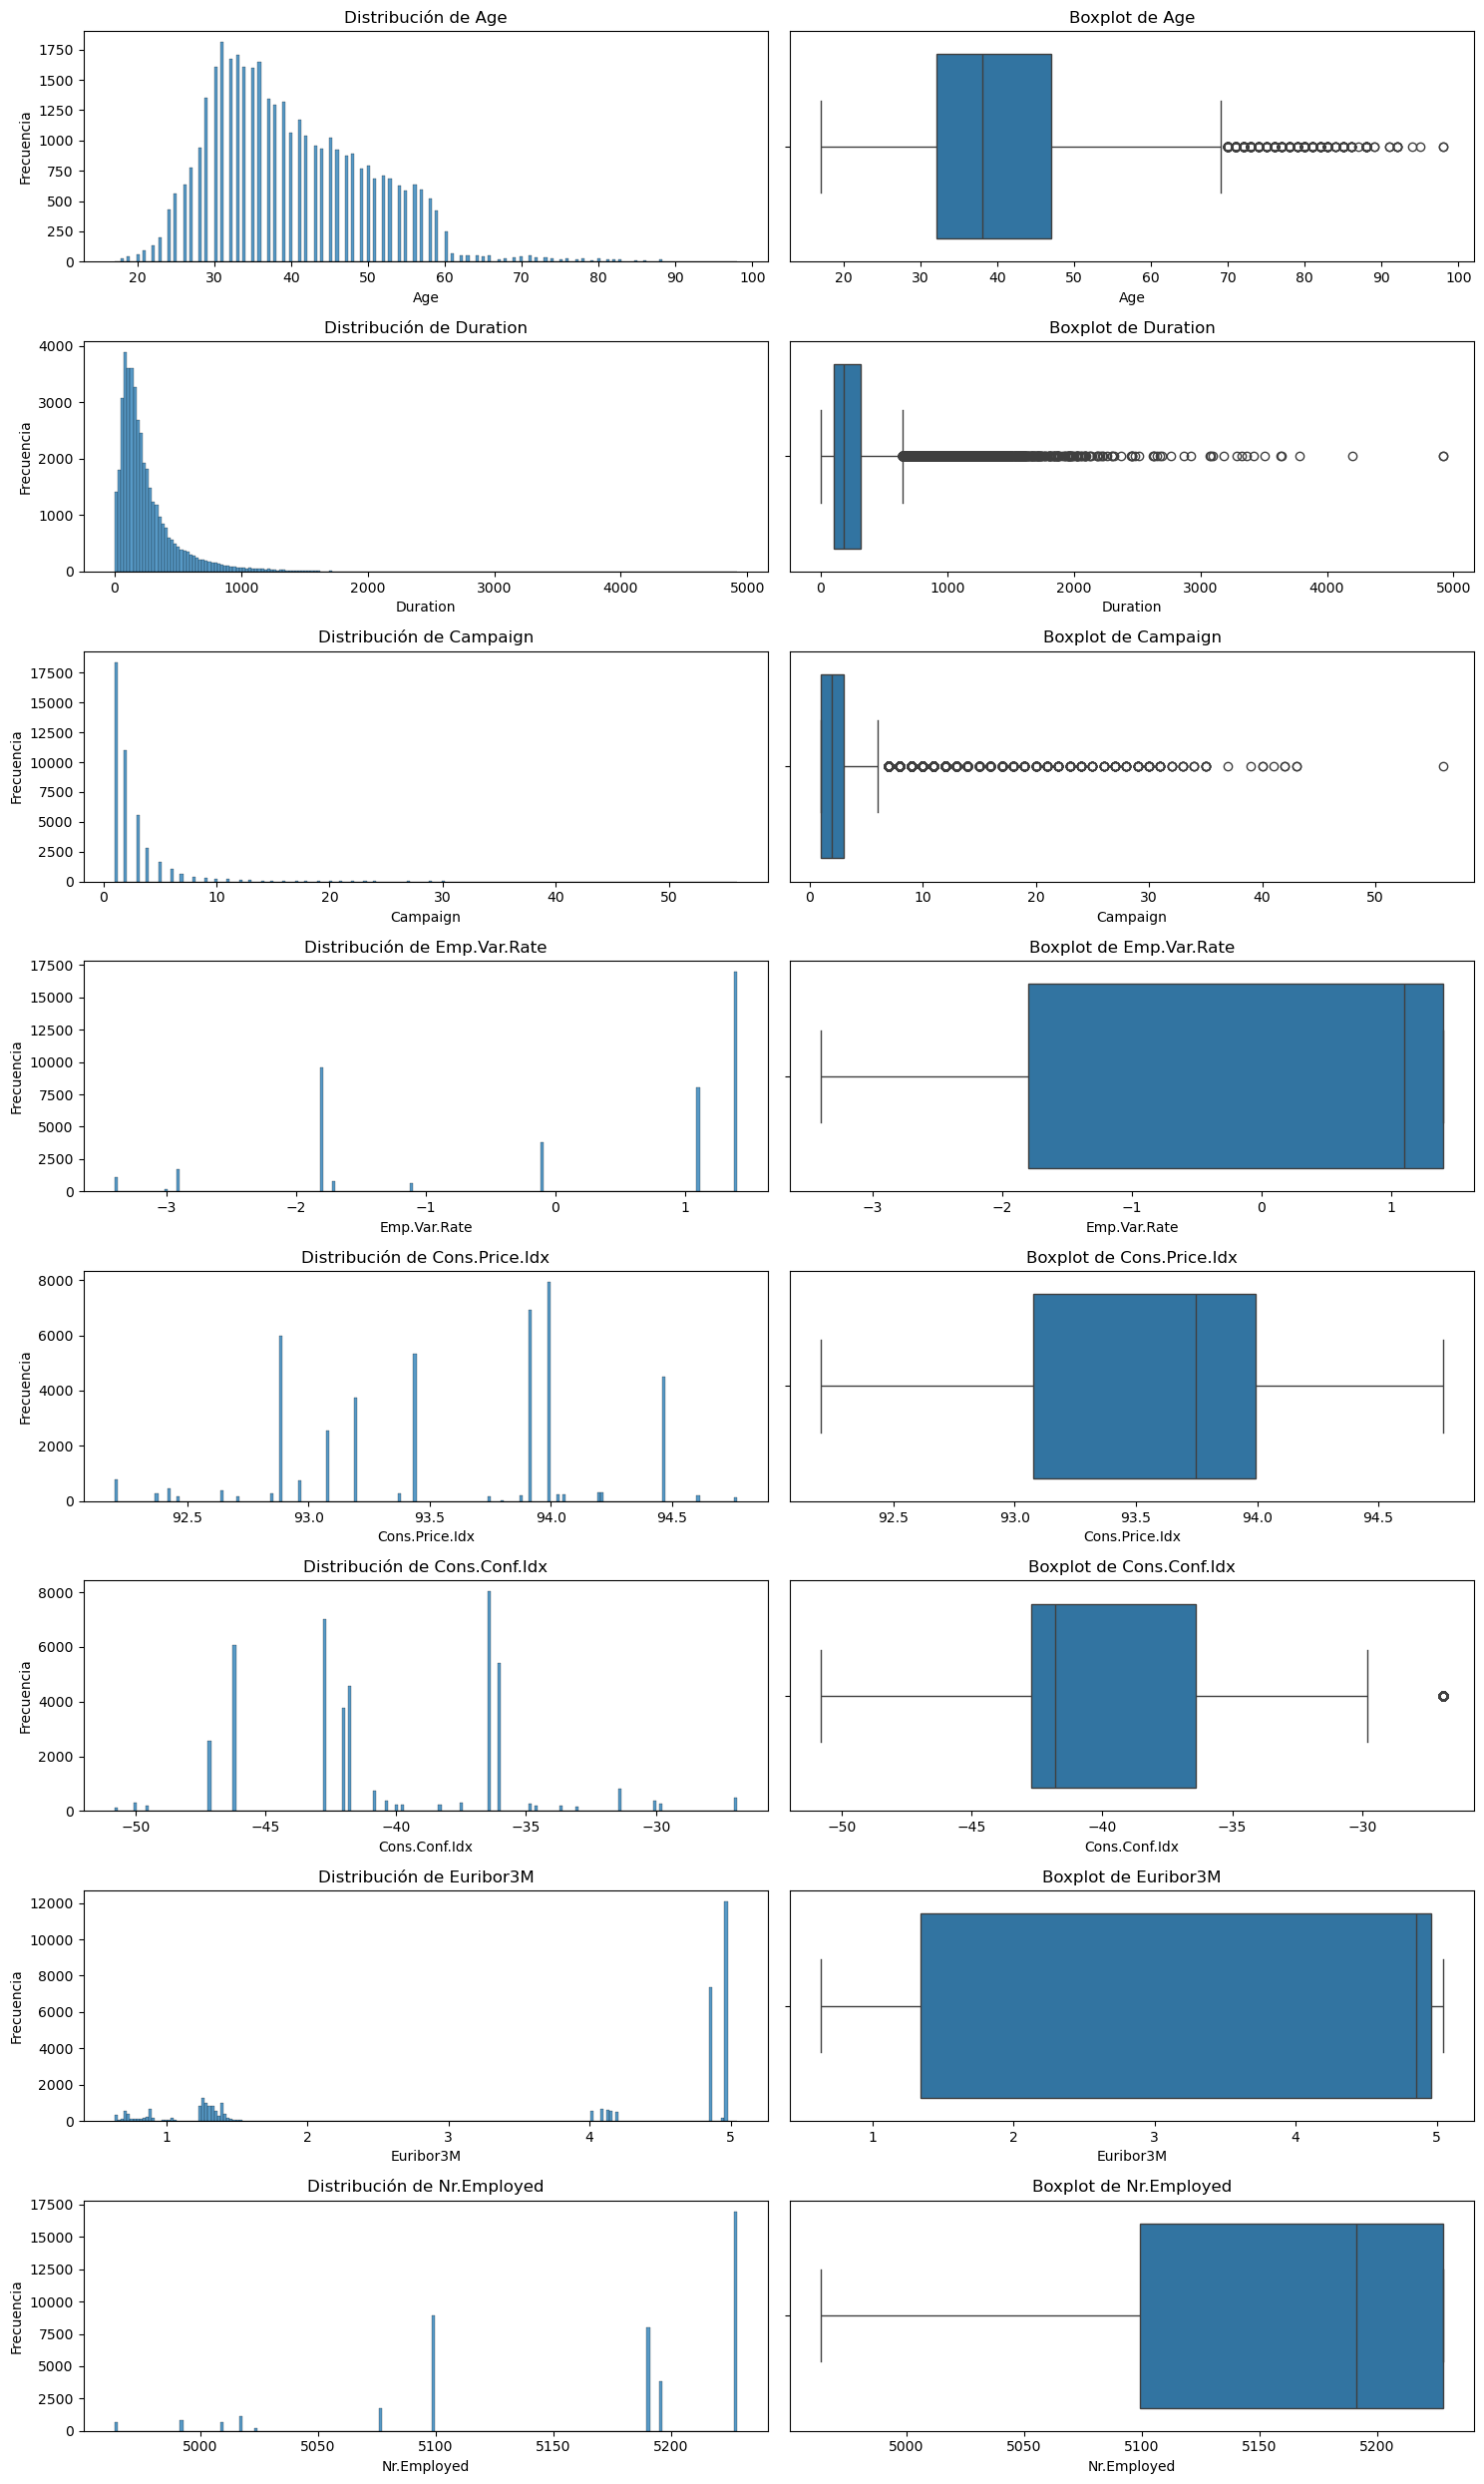

In [22]:
vis.subplot_col_num(df,columnas_num) 

In [23]:
# Se calculan los outliers usando el método del rango intercuartílico (IQR).
sp_eda.contar_outliers(df)

Para la columna AGE tenemos 441 outliers, lo que representa un 1.03% de los datos.
Para la columna DURATION tenemos 3072 outliers, lo que representa un 7.14% de los datos.
Para la columna CAMPAIGN tenemos 2504 outliers, lo que representa un 5.82% de los datos.
Para la columna PDAYS tenemos 1588 outliers, lo que representa un 3.69% de los datos.
Para la columna PREVIOUS tenemos 5897 outliers, lo que representa un 13.71% de los datos.
Para la columna EMP.VAR.RATE tenemos 0 outliers, lo que representa un 0.0% de los datos.
Para la columna CONS.PRICE.IDX tenemos 0 outliers, lo que representa un 0.0% de los datos.
Para la columna CONS.CONF.IDX tenemos 477 outliers, lo que representa un 1.11% de los datos.
Para la columna EURIBOR3M tenemos 0 outliers, lo que representa un 0.0% de los datos.
Para la columna NR.EMPLOYED tenemos 0 outliers, lo que representa un 0.0% de los datos.
Para la columna LATITUDE tenemos 0 outliers, lo que representa un 0.0% de los datos.
Para la columna LONGITUDE tenem

In [24]:
# Elimino los outliers que no son representativos usando el método IQR reemplazándolos por la mediana 

columnas_a_ajustar = ["Age", "Duration", "Campaign", "Pdays", "Cons.Conf.Idx"]
sp_eda.eliminar_outliers(df, columnas_a_ajustar)

In [25]:
# Gestión de nulos de la columnas numéricas
high_umbral, low_umbral= sp_eda.calcular_solo_col_nul(df, umbral=5) 

,Column,Datatype,NullCount,Null%
0,Age,float64,5120,11.906977
1,Cons.Price.Idx,float64,471,1.095349
2,Euribor3M,float64,9256,21.525581
3,Date,datetime64[ns],248,0.576744
4,Year,float64,248,0.576744
5,Quarter,float64,248,0.576744


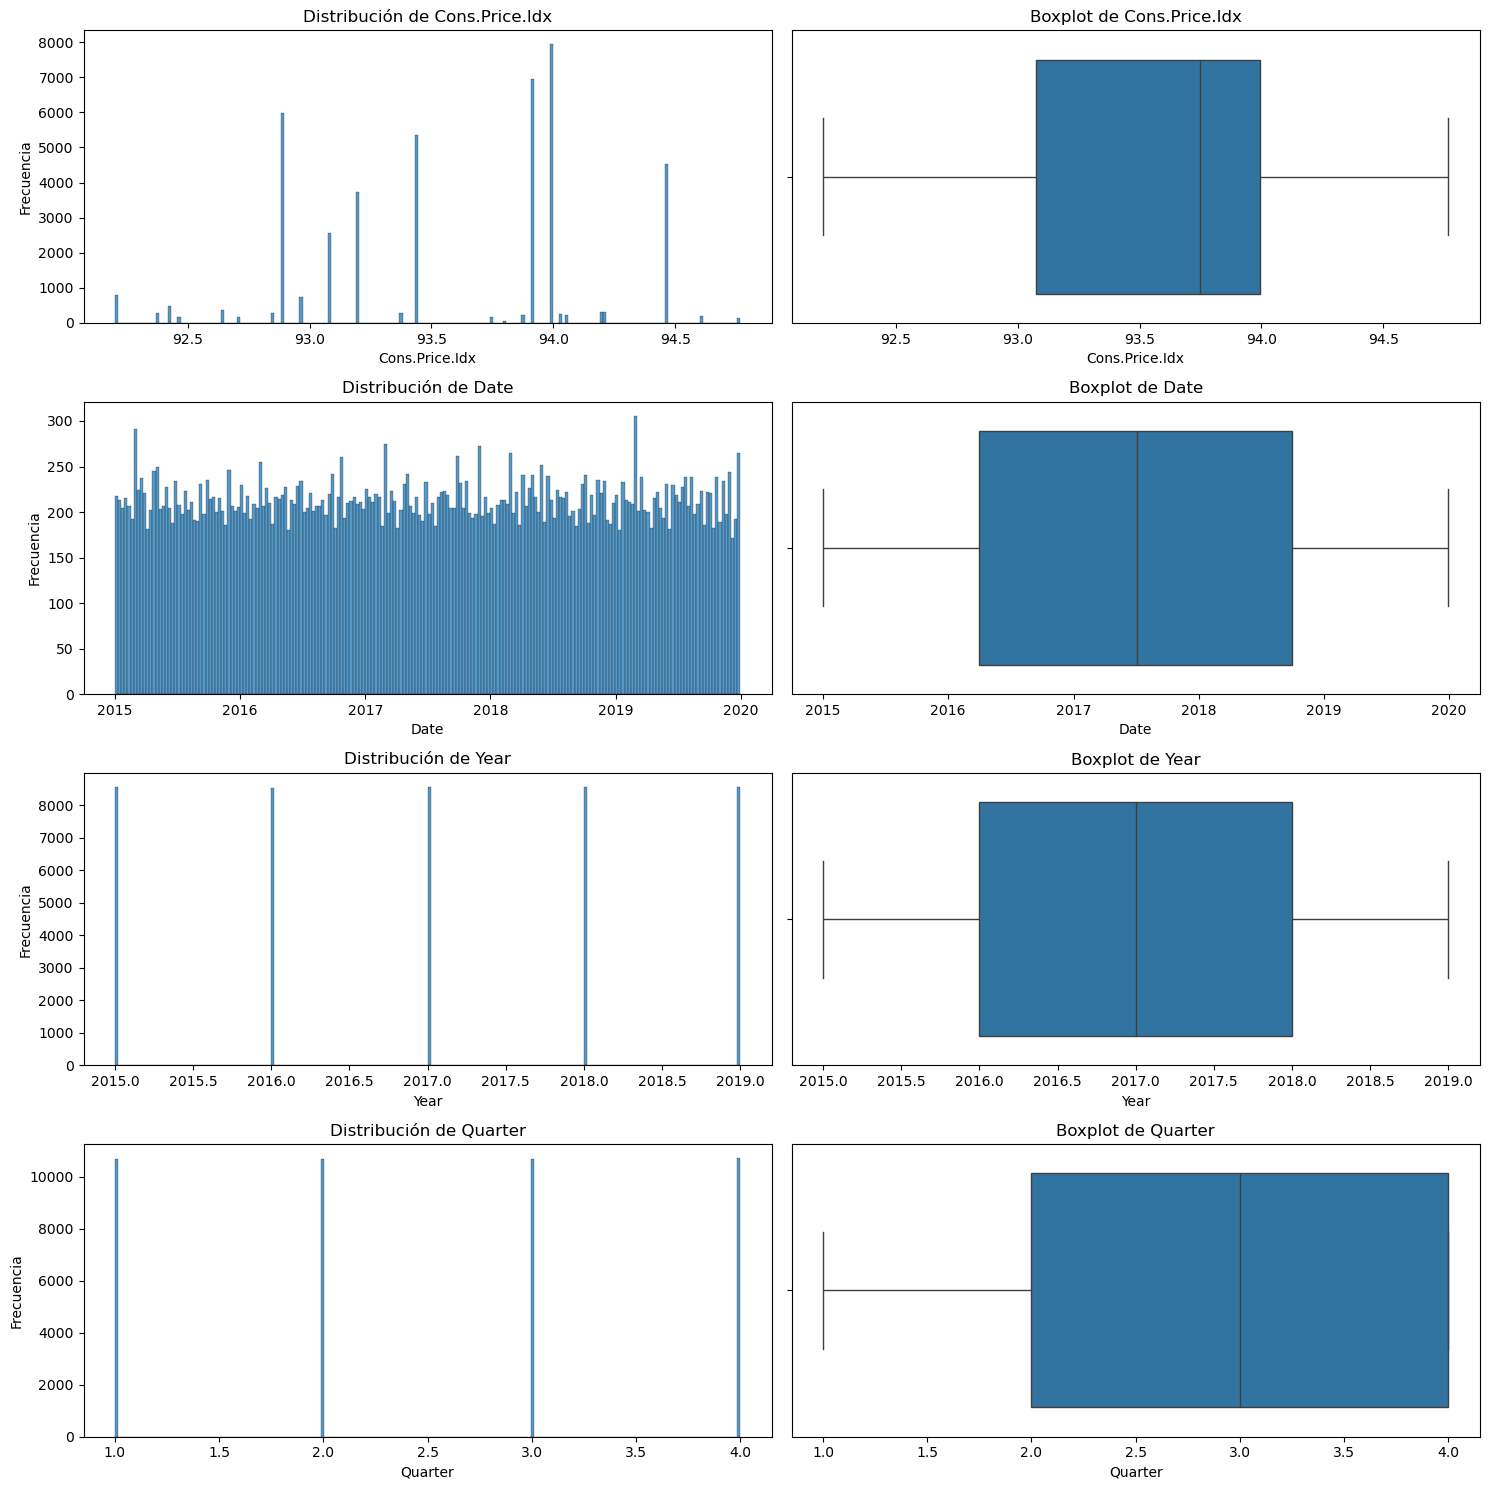

In [26]:
vis.subplot_col_num(df,low_umbral)

In [27]:
# Las columnas con un % de nulos inferior al umbral se imputarán con el método fillna() reemplazándolos por la mediana 

df=df.fillna({
    'Cons.Price.Idx': df['Cons.Price.Idx'].median(),
    'Date': df['Date'].median(),
    'Year': 2017,
    'Quarter': 3 
})

df[low_umbral].describe().T

,count,mean,min,25%,50%,75%,max,std
Cons.Price.Idx,43000.0,93.576134,92.201,93.075,93.749,93.994,94.767,0.576652
Date,43000,2017-07-01 20:13:13.004651264,2015-01-01 00:00:00,2016-04-04 00:00:00,2017-07-04 00:00:00,2018-09-30 00:00:00,2019-12-31 00:00:00,NaN
Year,43000.0,2017.001302,2015.0,2016.0,2017.0,2018.0,2019.0,1.410228
Quarter,43000.0,2.504209,1.0,2.0,3.0,3.0,4.0,1.115895


In [34]:
# Las columnas con un % de nulos superior al umbral se imputarán con el método iterativeimputer y knn según cada caso particular

In [35]:
# Iterative Imputer para Age
iter_imputer = IterativeImputer()
df['Age'] = iter_imputer.fit_transform(df[['Age']])

# KNN Imputer para Euribor3M
knn_imputer = KNNImputer(n_neighbors=5)
df['Euribor3M'] = knn_imputer.fit_transform(df[['Euribor3M']])


In [36]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Age,43000.0,39.523284,17.0,33.0,39.523284,45.0,69.0,9.025124
Duration,43000.0,201.395372,0.0,102.0,179.0,264.0,644.0,135.902159
Campaign,43000.0,2.042047,1.0,1.0,2.0,3.0,6.0,1.242124
Pdays,43000.0,999.0,999.0,999.0,999.0,999.0,999.0,0.0
Previous,43000.0,0.174023,0.0,0.0,0.0,0.0,7.0,0.497366
Emp.Var.Rate,43000.0,0.077128,-3.4,-1.8,1.1,1.4,1.4,1.573898
Cons.Price.Idx,43000.0,93.576134,92.201,93.075,93.749,93.994,94.767,0.576652
Cons.Conf.Idx,43000.0,-40.674335,-50.8,-42.7,-41.8,-36.4,-29.8,4.409095
Euribor3M,43000.0,3.616521,0.634,1.466,4.076,4.959,5.045,1.538834
Nr.Employed,43000.0,5166.852602,4963.6,5099.1,5191.0,5228.1,5228.1,72.411125


In [37]:
# guardo el archivo 
df.to_csv('../data_processed/ba_limpieza.csv', index=False)